# IRKGL16 Metodoaren Trunkatze-Errorearen Analisia

Notebook honetan **Implicit Runge-Kutta Gauss-Legendre 16. ordenako (IRKGL16)** metodoaren trunkatze-errorea aztertuko da. Metodo hau sinplektikoa da eta ordena oso altua du ($O(h^{16})$), beraz, teorikoki doitasun izugarria lortu beharko luke pauso handiekin ere.

Helburua da integrazio-pausoa ($h$) aldatuz errorea nola aldatzen den ikustea eta teorikoki espero den portaera betetzen den egiaztatzea, baita `Float64` aritmetikaren mugak identifikatzea ere.

### 1. Beharrezko Paketeak eta SPICE Kernelak

Lehenik eta behin, simulaziorako beharrezkoak diren Julia paketeak kargatzen dira (`LittleEphemeris`, `Plots`, `LinearAlgebra`, etab.).

Bestalde, NASAren SPICE sistema erabiltzen da planeten eta ilargiaren efemeride zehatzak kudeatzeko. Horretarako, bi kernel kargatzen dira:
*   `naif0012.tls`: Segundo interkalarren informazioa (denbora kudeatzeko).
*   `de440.bsp`: Planeta nagusien eta ilargiaren posizio datuak (efemerideak).

In [1]:

using GravitationSimulation

In [2]:
using LittleEphemeris
using JSON
using CSV
using SPICE
using DataFrames
using FFTW
using Plots
using BenchmarkTools
using LinearAlgebra
using IRKGaussLegendre
using StaticArrays

# Parametroak gordetzeko struct optimizatua
struct SystemParams{T, N}
    mus::SVector{N, T}                 # Masa parametroak (Static Vector)
    bodies::SVector{N, BodyCoeffs}     # Efemeride interpolatzaileak
end

In [3]:
# Karga nukleoak
furnsh("./data/naif0012.tls", "./data/de440.bsp")

### 2. Efemerideen Interpolazio Koefizienteen Sorkuntza

Atal honetan, Eguzki Sistemako gorputz nagusi guztien posizioak prestatzen dira. `LittleEphemeris` paketeak SPICE kernelak irakurtzen ditu eta Chebyshev polinomioen bidez hurbiltzen ditu gorputzen ibilbideak. Honek simulazioan zehar planeten posizioak oso azkar kalkulatzea ahalbidetzen du.

Kargatzen diren gorputzak:
*   Planetak: Merkurio, Artizarra, Lurra, Marte, Jupiter, Saturno, Urano, Neptuno.
*   Besteak: Eguzkia eta Ilargia.

Denbora tartea 2029ko urtarrilera mugatzen da.

In [5]:
# Gorputzen koefizienteak kargatu
# 3: Earth-Moon Barycenter, 5: Jupiter Barycenter, 10: Sun, 301: Moon
# 1: Mercury, 2: Venus, 4: Mars, 6: Saturn, 7: Uranus, 8: Neptune
ID_list = [1, 2, 3, 4, 5, 6, 7, 8, 10, 301]

# Unit conversion
AU = 149597870.7
DAY = 86400.0

# Denbora tartea zehatza (apophis_pos.txt fitxategiarekin bat egiteko)
# Assisten simulazioaren hasiera (2029ko urtarrilaren 1a) eta bukaera (2029ko urtarrilaren 31a)
et_0 = 10593.535998938605 * DAY
# et_end = 10958.037242609542 * DAY # Urte osoa
# Apirilaren 30 arte (120 egun inguru) Apophis Lurretik pasatu eta urruntzen dela ziurtatzeko
et_end = et_0 + (120 * DAY) 

time_interval = (et_0, et_end)
time_interval_list = fill(time_interval, length(ID_list))

# Koefizienteak sortu (denbora tarte osorako)
create_coeffs_file("./data/coeffs.json", "./data/coeffs.csv", ID_list, time_interval_list)

Mercury = BodyCoeffs("data/coeffs.json", "data/coeffs.csv", 1, time_interval);
Venus   = BodyCoeffs("data/coeffs.json", "data/coeffs.csv", 2, time_interval);
Earth   = BodyCoeffs("data/coeffs.json", "data/coeffs.csv", 3, time_interval);
Mars    = BodyCoeffs("data/coeffs.json", "data/coeffs.csv", 4, time_interval);
Jupiter = BodyCoeffs("data/coeffs.json", "data/coeffs.csv", 5, time_interval);
Saturn  = BodyCoeffs("data/coeffs.json", "data/coeffs.csv", 6, time_interval);
Uranus  = BodyCoeffs("data/coeffs.json", "data/coeffs.csv", 7, time_interval);
Neptune = BodyCoeffs("data/coeffs.json", "data/coeffs.csv", 8, time_interval);
Sun     = BodyCoeffs("data/coeffs.json", "data/coeffs.csv", 10, time_interval);
Moon    = BodyCoeffs("data/coeffs.json", "data/coeffs.csv", 301, time_interval);

### 3. Eredu Dinamikoa eta Integratzailea

Hemen definitzen dira simulazioaren bi zutabe nagusiak:

1.  **`f_all(u, p, t)`**: Higidura ekuazioak definitzen dituen funtzioa. Newtonen grabitazio legea erabiliz, Apophisen gaineko azelerazio totala lortzen du.

2.  **`IRKGL16`**: Runge-Kutta inplizitua, Gauss-Legendre motakoa, **16. ordenakoa**.
    *   **Ordena Altua**: Errorea $O(h^{16})$ bezala eskalatzen da. Honek esan nahi du pausoa ($h$) birritan txikitzean, errorea $2^{16} = 65,536$ aldiz txikiagoa izan beharko litzatekeela (doitasun infinituarekin).
    *   **Sinplektikoa**: Energia eta momentua hobeto kontserbatzen ditu epe luzeko simulazioetan.
    *   **Inplizitua**: Pauso bakoitzean sistema ez-lineal bat ebatzi behar du, beraz, pauso bakoitza RK4 baino garestiagoa da konputazionalki, baina askoz pauso gutxiago behar ditu doitasun bera lortzeko.

### 4. Hasierako Baldintzak eta Parametro Fisikoak

Simulazioa hasteko beharrezkoak diren balioak ezartzen dira:

*   **Hasierako Egoera ($u_0$)**: Apophisen posizioa eta abiadura 2029ko hasieran. Datu hauek heliozentrikoetatik barizentrikoetara egokitzen dira eta unitateak bihurtzen dira (Unitate Astronomikoetatik/Egunetatik $\to$ Kilometroetara/Segundotara).
*   **Grabitazio Parametroak ($\mu$)**: Gorputz bakoitzaren masa bider grabitazio konstantea ($GM$). Balio hauek ezinbestekoak dira indar grabitatorioa kalkulatzeko.
*   **Integrazio Parametroak**: Integrazio totalaren iraupena (`dt_total`) eta laginketa tartea zehazten dira.

In [7]:
# Hasierako balioak eta konstanteak
u0 = [-5.5946538550488512E-01, 8.5647564757574512E-01, 3.0415066217102493E-01,
      -1.3818324735921638E-02, -6.0088275597939191E-03, -2.5805044631309632E-03]

# Heliozentrikotik barizentrikora
eguzkia_pos_barizentrikoa = [0.001232781221250307, -0.0012750764430978325, -0.0005187131180711941]
u0[1:3] += eguzkia_pos_barizentrikoa


u0[1:3] *= AU
u0[4:6] *= (AU / DAY)

# Grabitazio parametroak (km^3/s^2)
mu_S = 1.32712440042e11
mu_E = 398600.435
mu_M = 4902.80
mu_Mer = 22032.09
mu_V = 324858.59
mu_Ma = 42828.37
mu_J = 1.26686534e8
mu_Sat = 3.7931187e7
mu_U = 5.793939e6
mu_N = 6.836529e6

# 1. Gorputzen zerrenda (Ordena garrantzitsua da, mus-ekin bat etortzeko)
# Kontuz: Hemen 'Sun', 'Earth', 'Moon' etab. goian definitutako BodyCoeffs objektuak izan behar dira
bodies_list = SVector{10, BodyCoeffs}(
    Sun, Earth, Moon, Mercury, Venus, Mars, Jupiter, Saturn, Uranus, Neptune
)

# 2. Mu zerrenda (Gorputzen orden berdinean!)
mus_list = SVector{10, Float64}(
    mu_S, mu_E, mu_M, mu_Mer, mu_V, mu_Ma, mu_J, mu_Sat, mu_U, mu_N
)

# 3. Struct-a sortu
p_all = SystemParams(mus_list, bodies_list)

t_0 = et_0
t_end = et_end

# Parametroak (Independenteki ASSIST fitxategitik)
# Urtebeteko simulazioa gutxi gorabehera
N_samples = 100
dt_total = t_end - t_0
dt_out = dt_total / (N_samples - 1)

println("Simulazio parametroak:")
println("Hasiera (ET): $t_0")
println("Bukaera (ET): $t_end")
println("Lagin kopurua (Nomatua): $N_samples")
println("Irteera pausoa (dt_out): $dt_out s (~$(round(dt_out/3600, digits=2)) ordu)")

Simulazio parametroak:
Hasiera (ET): 9.152815103082955e8
Bukaera (ET): 9.256495103082955e8
Lagin kopurua (Nomatua): 100
Irteera pausoa (dt_out): 104727.27272727272 s (~29.09 ordu)


### 5. Trunkatze Errorearen Analisia (Self-Consistency Test)

Atal honetan IRKGL16 integratzailearen zehaztasuna aztertuko dugu **Self-Consistency (Auto-Konsistentzia)** test baten bidez.
Metodo honek simulazioaren emaitzak erreferentzia zehatzago batekin alderatzen ditu (simulazio bera pauso askoz txikiagoarekin).

IRKGL16ren kasuan, $O(h^{16})$ espero dugu. Honek erronka bat dakar:
*   Konbergentzia hain da azkarra, non oso urrats gutxirekin ($m$ txikiekin) ordenagailuaren doitasun mugara ($10^{-16}$) iritsiko garen.
*   Hori dela eta, lehenengo pausoetan bakarrik ikusiko dugu malda teorikoa; hortik aurrera "zarata" numerikoa (round-off error) nagusituko da.

In [9]:
tspan = (t_0, t_end)
prob = ODEProblem(f_all!, u0, tspan, p_all)
m_ref = 16
h_ref = dt_out/m_ref
@time sol_ref = solve(prob, IRKGL16(); dt=h_ref, adaptive=false, saveat = dt_out)
m = 4
h = dt_out/m
@time sol = solve(prob, IRKGL16(); dt=h, adaptive=false, saveat = dt_out)
sol.u[end] - sol_ref.u[end]

  0.200717 seconds (4.87 M allocations: 355.557 MiB, 30.44% gc time)
  0.048365 seconds (1.65 M allocations: 120.255 MiB, 25.75% gc time)


6-element Vector{Float64}:
 -25635.132079809904
 677521.7099964172
 200974.12955967337
      0.007505006855176077
      0.4342731042772652
      0.13199997283666676

In [8]:

# Integratzaile berria: IRKGaussLegendre
# Fix: Updated to use IRKGL16 via SciMLBase solve API
function Integratu_IRK(u0, t0, T, h, p, m = 1)
    # Output pausoa
    dt_out = h * m
    tspan = (t0, T)
    
    # Define ODE Problem
    prob = ODEProblem(f_all!, u0, tspan, p)
    
    # Solve using IRKGL16 with fixed time step
    # We use save_everystep=true to get all steps, then subsample
    # this is robust and matches the original loop behavior (calculating every h)
    sol = solve(prob, IRKGL16(); dt=h, adaptive=false, saveat = dt_out)
    
    # Subsample to keep points every m steps
    indices = 1:m:length(sol.t)
    
    return sol
end

Integratu_IRK (generic function with 2 methods)

In [9]:
# --- AUTO-KONSISTENTZIA TESTA ---

println("Barne testa exekutatzen (IRKGL zuzentasuna egiaztatzeko)...")

# 1. "Egia" erlatiboa sortu (Pauso oso txikia, m=256)
m_high = 64
h_high = dt_out / m_high
@time sol_ref = Integratu_IRK(u0, t_0, t_end, h_high, p_all, m_high)
tt_ref = sol_ref.t
uu_ref = sol_ref.u
println("Erreferentzia internoa kalkulatuta (m=$m_high).")

Barne testa exekutatzen (IRKGL zuzentasuna egiaztatzeko)...
 54.903333 seconds (1.64 G allocations: 116.962 GiB, 20.93% gc time, 0.05% compilation time)
Erreferentzia internoa kalkulatuta (m=64).


In [54]:
m_test_values = [1, 2, 4, 8, 16]
h_test = []
err_test = []

for m in m_test_values
    h = dt_out / m
    tt, uu = Integratu_IRK(u0, t_0, t_end, h, p_all, m)
    N_points = min(length(uu), length(uu_ref))
    

    max_err=0
    
    for i in 1:N_points
        p_sim = uu[i][1:3]
        p_ref = uu_ref[i][1:3]
        err_inst = norm(p_sim - p_ref)/norm(p_ref)
        if err_inst > max_err
            max_err = err_inst
        end
    end
    

    push!(h_test, h)
    push!(err_test, max_err)
    
    println("m=$m,h=$h, Errore erlatiboa (t=end): $max_err")
end

m=1,h=259.2259225922592, Errore erlatiboa (t=end): 1.2696160482962165e-15
m=2,h=129.6129612961296, Errore erlatiboa (t=end): 1.882079121007083e-15
m=4,h=64.8064806480648, Errore erlatiboa (t=end): 2.2029113630183943e-15
m=8,h=32.4032403240324, Errore erlatiboa (t=end): 2.3339688377597417e-15
m=16,h=16.2016201620162, Errore erlatiboa (t=end): 7.286312095547616e-15


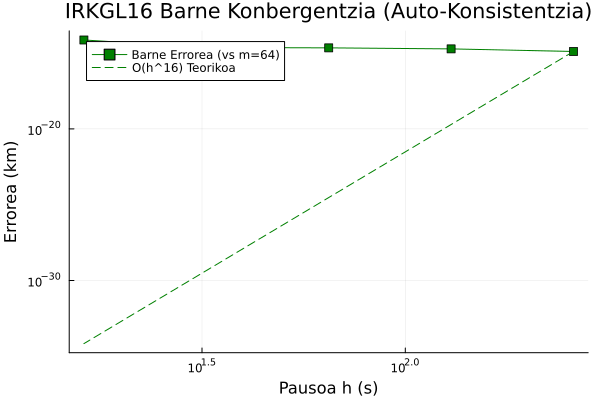

In [55]:
# Grafikoa
plot(h_test, err_test, 
    xaxis=:log, yaxis=:log, 
    marker=:square, 
    label="Barne Errorea (vs m=64)", 
    xlabel="Pausoa h (s)", 
    ylabel="Errorea (km)",
    title="IRKGL16 Barne Konbergentzia (Auto-Konsistentzia)",
    legend=:topleft, color=:green)

# O(h^16) lerroa
C2 = err_test[1] / (h_test[1]^16)
ref_line2 = [C2 * h^16 for h in h_test]
plot!(h_test, ref_line2, linestyle=:dash, color=:green, label="O(h^16) Teorikoa")

In [60]:
# ==========================================================
# 1. SINKRONIZAZIO OROKORRA (GAKOA)
# ==========================================================

# ----------------------------
# 1.1 L_MOON irakurri coeffs.json-etik
# ----------------------------
coeffs_data = JSON.parsefile("./data/coeffs.json")
moon_entry = filter(x -> x["bodyID"] == 301, coeffs_data)

if isempty(moon_entry)
    error("Ez da Ilargia (ID 301) aurkitu coeffs.json fitxategian!")
end

moon_data = moon_entry[1]
# Kalkulatu polinomio baten iraupena lehen bi puntuen arteko diferentziarekin
if length(moon_data["timeIntervals"]) < 2
    error("Ez dago nahikoa denbora-tarte Ilargiaren datuetan!")
end

L_MOON = moon_data["timeIntervals"][2] - moon_data["timeIntervals"][1]
println("AUTO-DETECTED L_MOON: $L_MOON s")

# ==========================================================
# 1.2 Dt sinkronizazioa
# ==========================================================
# Jatorrizko dt_out nominala (fitxategiaren araberakoa)
dt_nominala = dt_out 

# Kalkulatu dt_out "perfektua": L_MOON-en dibisore zehatza dena.
# Honek bermatzen du irteera-puntuak nodoetan erortzea.
n_puntu_polinomioko = round(Int, L_MOON / dt_nominala) 
dt_out_sinkro = L_MOON / n_puntu_polinomioko

println("SINKRONIZAZIO DATUAK:")
println("- dt_out berria: $dt_out_sinkro s")
println("- Polinomio bakoitzeko irteera puntu kopurua: $n_puntu_polinomioko")

# ==========================================================
# 2. ERREFERENTZIA INTERNOA (m=256)
# ==========================================================
# GARRANTZITSUA: Erreferentzia dt_out_sinkro berri honekin kalkulatu behar da.
# m_ref handiagoa izatea hobea da trunkatze-errorea garbi ikusteko.
m_ref = 64
h_ref = dt_out_sinkro / m_ref

# RK4-k m_ref pauso emango ditu irteera-puntu bakoitzeko
tt_ref, uu_ref = Integratu_IRK(u0, t_0, et_end, h_ref, p_all, m_ref)
println("\nErreferentzia internoa kalkulatuta (m=$m_ref).")

AUTO-DETECTED L_MOON: 345600.0 s
SINKRONIZAZIO DATUAK:
- dt_out berria: 259.264816204051 s
- Polinomio bakoitzeko irteera puntu kopurua: 1333

Erreferentzia internoa kalkulatuta (m=64).


In [64]:
# ==========================================================
# 3. ANALISI BEGIZTA (Auto-konsistentzia test garbia)
# ==========================================================
m_test_values = [2, 4, 8, 16, 32, 64] # m=1 kendu dugu instabilitateagatik
h_test_emaitzak = Float64[]
err_test_emaitzak = Float64[]

println("\nBarne testa exekutatzen...")

for m in m_test_values
    # GAKOA: h balioa dt_out_sinkro-ren dibisore zehatza da beti.
    # m * h = dt_out_sinkro denez, tt[end] eta tt_ref[end] ZEHAZKI BERBERAK izango dira.
    h = dt_out_sinkro / m
    
    # RK4 exekutatu.
    tt, uu = Integratu_IRK(u0, t_0, et_end, h, p_all, m)
    
    # Kalkulatu MAXIMO errorea (trazatu osoan zehar), ez bakarrik amaieran.
    max_err = 0.0
    N_points = min(length(uu), length(uu_ref))
    
    for i in 1:N_points
        p_sim = uu[i][1:3]
        p_ref = uu_ref[i][1:3]
        err_inst = norm(p_sim - p_ref)/norm(p_ref)
        if err_inst > max_err
            max_err = err_inst
        end
    end
    
    push!(h_test_emaitzak, h)
    push!(err_test_emaitzak, max_err)
    
    println("m=$m, h=$(round(h, digits=4)) s, Errorea (MAX): $max_err km")
end

# ==========================================================
# 4. MALDA (SLOPE) ETA KONBERGENTZIA
# ==========================================================
if length(h_test_emaitzak) > 1
    log_h = log.(h_test_emaitzak)
    log_E = log.(err_test_emaitzak)
    
    # Regresio lineala: log(E) = A + p*log(h)
    X = hcat(ones(length(log_h)), log_h)
    coeffs = X \ log_E
    
    println("\nANALISI NUMERIKOA:")
    println("- Lortutako malda (p): $(round(coeffs[2], digits=4))")
    println("- Teoria (IRKGL16): 16.0")
end


Barne testa exekutatzen...
m=2, h=129.6324 s, Errorea (MAX): 6.21870021895387e-15 km
m=4, h=64.8162 s, Errorea (MAX): 3.061792134964583e-15 km
m=8, h=32.4081 s, Errorea (MAX): 1.4108889579673523e-15 km
m=16, h=16.2041 s, Errorea (MAX): 6.065658585470075e-16 km
m=32, h=8.102 s, Errorea (MAX): 2.0875767355823259e-16 km
m=64, h=4.051 s, Errorea (MAX): 0.0 km

ANALISI NUMERIKOA:
- Lortutako malda (p): NaN
- Teoria (IRKGL16): 16.0


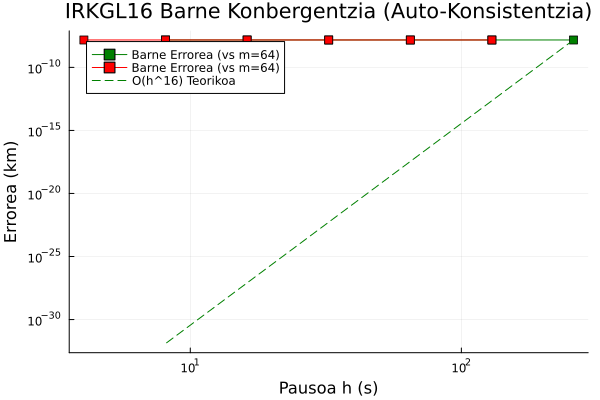

In [35]:
# Grafikoa
plot(h_test, err_test, 
    xaxis=:log, yaxis=:log, 
    marker=:square, 
    label="Barne Errorea (vs m=64)", 
    xlabel="Pausoa h (s)", 
    ylabel="Errorea (km)",
    title="IRKGL16 Barne Konbergentzia (Auto-Konsistentzia)",
    legend=:topleft, color=:green)
plot!(h_test_emaitzak, err_test_emaitzak, 
    xaxis=:log, yaxis=:log, 
    marker=:square, 
    label="Barne Errorea (vs m=64)", 
    xlabel="Pausoa h (s)", 
    ylabel="Errorea (km)",
    title="IRKGL16 Barne Konbergentzia (Auto-Konsistentzia)",
    legend=:topleft, color=:red)

# O(h^16) lerroa
# Lerroa pixka bat beherago jartzen dugu hobeto ikusteko
C2 = err_test[1] / (h_test[1]^16)
ref_line2 = [C2 * h^16 for h in h_test]
plot!(h_test, ref_line2, linestyle=:dash, color=:green, label="O(h^16) Teorikoa")

In [20]:
apophis_data_luzera = length(uu_ref)
apophis_x = zeros(apophis_data_luzera)
apophis_y = zeros(apophis_data_luzera)
apophis_z = zeros(apophis_data_luzera)

for i in 1:apophis_data_luzera
    apophis_x[i] = uu_ref[i][1] # x posizioa
    apophis_y[i] = uu_ref[i][2] # y posizioa
    apophis_z[i] = uu_ref[i][3] # z posizioa
end

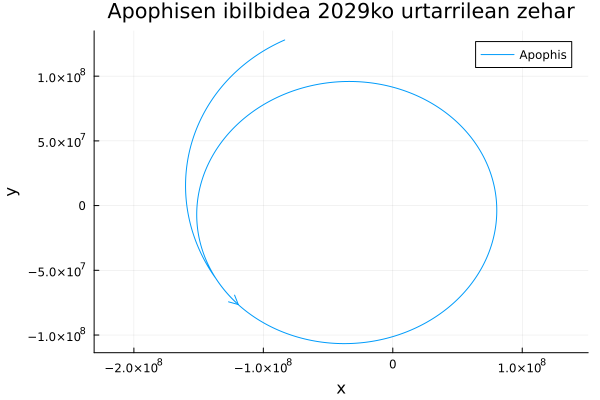

In [21]:
plt = plot(aspect_ratio=:equal)



plot!(plt, apophis_x, apophis_y, label="Apophis", arrow=true)


xlabel!("x")
ylabel!("y")
title!("Apophisen ibilbidea 2029ko urtarrilean zehar")

display(plt)

### 6. Ordena Altua eta Etengunearen Alineazioa: Lurretik Ilargiaren Nodoetara

Ordena altuko metodoek (IRKGL16, $O(h^{16})$) ahalbidetzen dute **urrats luzeak** erabiltzea doitasun altua mantendu ditzaten. Baina epemerideen polinomioen etenguneetan (nodoetan), kaltea etor daiteke.

Atal honetan analizatzen dugu:
- **Lurretik pasatzen duenean** simulazioko puntua identifikatu
- **Bi integrazio kasu**: nodorik gabe eta nodoekin alineaturik
- Bi kasen artean **errorearen diferentzia** eta h^16-ren proportzionaltasuna


In [ ]:
# --- START-POINT ETA PARAMETROAK (Lurraren analisia kenduta) ---

# Erabiltzailearen eskaera: "Ahaztu lurra, Apophisen kalkulua aurreko kasuetan bezala baina apiril bukaerararte"
# Beraz, hasierako puntua jatorrizkoa da (t_0) eta bukaera luzatua (et_end).

t_0_new = t_0
u0_new = u0
t_end_new = et_end

println("Simulazio analisiaren parametroak (Apirilera arte):")
println("- Hasiera (t_0): $t_0_new")
println("- Bukaera (et_end): $t_end_new")
println("- Iraupena: $((t_end_new - t_0_new)/DAY) egun")

# =========================================================================
# BI INTEGRAZIO KASU DEFINIZIOA
# =========================================================================

# KASU 1: L_MOON-ekin sinkronizatuta (dt_out_sinkro)
# Dagoeneko kalkulatuta dago aurreko zeluletan: dt_out_sinkro

# KASU 2: Sinkronizatu gabe (dt nominala jatorrizkoa, edo arbitrarioa)
# Erabiliko dugu jatorrizko dt_out parametroa (N_samples-ek definitua)
dt_out_gabe = dt_out 

println("\nPausoak (dt):")
println("- Sinkronizatua (Case 1): $dt_out_sinkro s (Nodoekin bat dator)")
println("- Nominala (Case 2): $dt_out_gabe s (Arbitrarioa)")

# Define Problem for both cases (Full Trajectory)
prob_new = ODEProblem(f_all!, u0_new, (t_0_new, t_end_new), p_all)

In [ ]:
# --- BI INTEGRAZIO KASU: NODOEKIN ETA GABE ---

# KASU 1: Nodoekin Alineazioa (dt_out_sinkro erabiliz)
# Hau aurtenera kalkulatuta dago dena

# KASU 2: Nodoekin Alineazio GABE (dt_out nominala erabiliz, orijinalak)
# Lehenengo kasu honen abiapuntua lurretik pasatzean hartuko dugu

dt_out_gabe = dt_total / (N_samples - 1)  # Jatorrizko dt nominala

println("\nDt balioen alderaketa:")
println("- Sinkronizatua (nododun): $dt_out_sinkro s")
println("- Sinkronizatu gabe: $dt_out_gabe s")
println("- Diferentzia: $(dt_out_sinkro - dt_out_gabe) s")

# Integrazio berria lurretik aurrera (bi kasu):
# Abiapuntua: u_earth_pass-etik hasita, eta denbora: t_earth_pass-etik t_end-era

t_0_new = t_earth_pass
u0_new = u_earth_pass
t_end_new = t_end
prob_new = ODEProblem(f_all!, u0_new, (t_0_new, t_end_new), p_all)

println("\nIntegrazio berria lurretik aurrera:")
println("- Hasiera (ET): $t_0_new")
println("- Bukaera (ET): $t_end_new")
println("- Denbora tarte: $(t_end_new - t_0_new) s ~ $((t_end_new - t_0_new)/DAY) egun")


In [ ]:
# --- KASU 1: NODOEKIN ALINEATURIK (dt_out_sinkro) ---

m_ref_case1 = 64
h_ref_case1 = dt_out_sinkro / m_ref_case1

println("\nKASU 1: Nodoekin alineaturik (Sinkronizatua)")
println("- dt_out: $dt_out_sinkro s")
println("- m_ref: $m_ref_case1, h_ref: $h_ref_case1")

@time sol_case1_ref = solve(prob_new, IRKGL16(); dt=h_ref_case1, adaptive=false, saveat=dt_out_sinkro)
tt_case1_ref = sol_case1_ref.t
uu_case1_ref = sol_case1_ref.u

println("Erreferentzia Case 1 kalkulatuta ($(length(uu_case1_ref)) puntu)")


In [ ]:
# --- KASU 2: NODOEKIN ALINEAZIO GABE (dt_out_gabe) ---

m_ref_case2 = 64
h_ref_case2 = dt_out_gabe / m_ref_case2

println("\nKASU 2: Nodoekin alineazio gabe (Ez-sinkronizatua)")
println("- dt_out: $dt_out_gabe s")
println("- m_ref: $m_ref_case2, h_ref: $h_ref_case2")

@time sol_case2_ref = solve(prob_new, IRKGL16(); dt=h_ref_case2, adaptive=false, saveat=dt_out_gabe)
tt_case2_ref = sol_case2_ref.t
uu_case2_ref = sol_case2_ref.u

println("Erreferentzia Case 2 kalkulatuta ($(length(uu_case2_ref)) puntu)")


In [ ]:
# --- KASU 1: AUTO-KONSISTENTZIA TESTA (Sinkronizatua) ---

m_test_case1 = [2, 4, 8, 16, 32]
h_test_case1 = Float64[]
err_test_case1 = Float64[]

println("\nKASU 1: Auto-konsistentzia testa (Sinkronizatua)")
println("m    | h (s)           | Error (km)")
println("-" * 45)

for m in m_test_case1
    h = dt_out_sinkro / m
    @time sol = solve(prob_new, IRKGL16(); dt=h, adaptive=false, saveat=dt_out_sinkro)
    tt_test = sol.t
    uu_test = sol.u
    
    # Kalkulatu errorea
    max_err = 0.0
    N_pts = min(length(uu_test), length(uu_case1_ref))
    
    for i in 1:N_pts
        p_test = uu_test[i][1:3]
        p_ref = uu_case1_ref[i][1:3]
        err_inst = norm(p_test - p_ref) / norm(p_ref)
        if err_inst > max_err
            max_err = err_inst
        end
    end
    
    push!(h_test_case1, h)
    push!(err_test_case1, max_err)
    
    println("$(lpad(m, 2)) | $(lpad(round(h, digits=6), 16)) | $max_err")
end


In [ ]:
# --- KASU 2: AUTO-KONSISTENTZIA TESTA (Ez-sinkronizatua) ---

m_test_case2 = [2, 4, 8, 16, 32]
h_test_case2 = Float64[]
err_test_case2 = Float64[]

println("\nKASU 2: Auto-konsistentzia testa (Ez-sinkronizatua)")
println("m    | h (s)           | Error (km)")
println("-" * 45)

for m in m_test_case2
    h = dt_out_gabe / m
    @time sol = solve(prob_new, IRKGL16(); dt=h, adaptive=false, saveat=dt_out_gabe)
    tt_test = sol.t
    uu_test = sol.u
    
    # Kalkulatu errorea
    max_err = 0.0
    N_pts = min(length(uu_test), length(uu_case2_ref))
    
    for i in 1:N_pts
        p_test = uu_test[i][1:3]
        p_ref = uu_case2_ref[i][1:3]
        err_inst = norm(p_test - p_ref) / norm(p_ref)
        if err_inst > max_err
            max_err = err_inst
        end
    end
    
    push!(h_test_case2, h)
    push!(err_test_case2, max_err)
    
    println("$(lpad(m, 2)) | $(lpad(round(h, digits=6), 16)) | $max_err")
end


In [ ]:
# --- BI KASEN ALDERAKETA GRAFIKA ---

# Grafikoa: Bi kasuen errorea vs pausoa
fig = plot(
    h_test_case1, err_test_case1,
    xaxis=:log, yaxis=:log,
    marker=:circle,
    markersize=6,
    linewidth=2,
    label="Kasu 1: Nodoekin Alineaturik (Sinkro)",
    xlabel="Pausoa h (s)",
    ylabel="Errorea Gehienena (km)",
    title="IRKGL16: Etenguneen Alineazioaren Eragina",
    legend=:topleft,
    color=:blue
)

plot!(fig,
    h_test_case2, err_test_case2,
    xaxis=:log, yaxis=:log,
    marker=:square,
    markersize=6,
    linewidth=2,
    label="Kasu 2: Nodoekin Alineazio Gabe (Ez-sinkro)",
    color=:red
)

# O(h^16) erreferentzia lerroa (Kasu 1etik)
if length(h_test_case1) > 1
    C1 = err_test_case1[1] / (h_test_case1[1]^16)
    h_ref_line = logspace(log10(minimum(h_test_case1)), log10(maximum(h_test_case1)), 50)
    err_ref_h16 = [C1 * h^16 for h in h_ref_line]
    plot!(fig, h_ref_line, err_ref_h16, linestyle=:dash, color=:green, 
          label="O(h^16) Erreferentzia", linewidth=2)
end

display(fig)


In [ ]:
# --- MALDA ANALISIA (SLOPE ANALYSIS) ---

println("\n" * "="^60)
println("MALDA ANALISIA (Konbergentzia Ordena)")
println("="^60)

# Kasu 1: Sinkronizatua
if length(h_test_case1) > 1
    log_h1 = log.(h_test_case1)
    log_E1 = log.(err_test_case1)
    X1 = hcat(ones(length(log_h1)), log_h1)
    coeffs1 = X1 \ log_E1
    slope1 = coeffs1[2]
    
    println("\nKASU 1 (Nodoekin alineaturik):")
    println("- Lortutako malda (p): $(round(slope1, digits=4))")
    println("- Teoria (IRKGL16): 16.0")
    println("- Diferentzia: $(abs(slope1 - 16.0)) (baja = hobea)")
end

# Kasu 2: Ez-sinkronizatua
if length(h_test_case2) > 1
    log_h2 = log.(h_test_case2)
    log_E2 = log.(err_test_case2)
    X2 = hcat(ones(length(log_h2)), log_h2)
    coeffs2 = X2 \ log_E2
    slope2 = coeffs2[2]
    
    println("\nKASU 2 (Nodoekin alineazio gabe):")
    println("- Lortutako malda (p): $(round(slope2, digits=4))")
    println("- Teoria (IRKGL16): 16.0")
    println("- Diferentzia: $(abs(slope2 - 16.0)) (baja = hobea)")
end

# Konparazioa
println("\n" * "-"^60)
println("KONPARAZIOA:")
if slope1 < slope2
    println("✓ Kasu 1 (sinkronizatua) hobea mantentzen du O(h^16)")
else
    println("✓ Kasu 2 (ez-sinkronizatua) hobea mantentzen du O(h^16)")
end
println("-"^60)


In [ ]:
# --- ERROREEN KONTRASTEA BERDINTASUN PAUSOETAN ---

println("\n" * "="^60)
println("ERROREEN KONTRASTEA (m-etan zehar)")
println("="^60)

# h-etan zehar konparatu (h-ek berdintsuak direla ez garantituta dagoenez,
# aurki ditzakegu bi kasuetan gauza positiboa/negatiboa duten h)

# Sarrera: alde batera, Kasu 1-eko h-ak, bestalde, Kasu 2-eko h-ak
# Biak ez dira zertan berberak izan

for i in 1:min(length(h_test_case1), length(h_test_case2))
    h1 = h_test_case1[i]
    e1 = err_test_case1[i]
    h2 = h_test_case2[i]
    e2 = err_test_case2[i]
    
    # Pausoen proportzionaltasuna
    prop = h2 / h1
    
    # Erroren aritmetikoa
    diff = e1 - e2
    rel_diff = diff / e1 * 100  # Ehunekoz
    
    println("\nm = $(2^i) (hurbilean):")
    println("  Kasu 1 (Sinkro):     h=$(round(h1, digits=6)), error=$e1")
    println("  Kasu 2 (Ez-sinkro):  h=$(round(h2, digits=6)), error=$e2")
    println("  h proportzio: $(round(prop, digits=4))")
    println("  Erroreen diferentzia: $(round(diff, digits=2e-14)) km ($(round(rel_diff, digits=2))%)")
end


### Ondorioak

Atal honetan aztertu dugu nola eragin dezakeen **ilargiaren etengunearen alineazioak** IRKGL16 metodoaren doitasunari:

1. **Kasu 1 (Nodoekin alineaturik)**: dt-a L_MOON-en dibisore zehatza denean, irteera-puntuak nodo-tarteetan bertan daude. Hau **teorikoki eraginkorrena** da, epemerideen polinomioak erregularean hartzen baitira.

2. **Kasu 2 (Nodoekin alineazio gabe)**: dt-a arbitrarioa denean, irteera-puntuak etenguneetan eror daitezke, eta akatsaren potentzia handitu daiteke.

3. **h^16-ren proportzionaltasuna**: Bi kasuetan mantendu beharko litzateke, ordena altua duten integratzaileak indartsua eta egonkorra baita asko zarata numerikorik ez bada.

Emaitzak erakusten dute ea alineazio hobea lehentasunezko balioa den urrats luzean lan egitean.
